In [335]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt

In [336]:
df=pd.read_csv("winequality_red.csv")

In [337]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [338]:
X=df.copy()


In [339]:
X.drop("quality",axis=1,inplace=True)

In [340]:
y = df["quality"]


In [341]:
y.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [342]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

In [343]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_Scaled=scaler.fit_transform(X_train)
X_test_Scaled=scaler.transform(X_test)

In [344]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train_Scaled,y_train)

LogisticRegression()

In [345]:
y_pred=model.predict(X_test)

c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [346]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.403125

Confusion Matrix:
 [[  0   0   0   0   1   0]
 [  0   0   5   0   5   0]
 [  0   0 104   2  24   0]
 [  0   0  99   5  28   0]
 [  0   0  21   1  20   0]
 [  0   0   3   0   2   0]]

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.45      0.80      0.57       130
           6       0.62      0.04      0.07       132
           7       0.25      0.48      0.33        42
           8       0.00      0.00      0.00         5

    accuracy                           0.40       320
   macro avg       0.22      0.22      0.16       320
weighted avg       0.47      0.40      0.31       320



c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

In [347]:
from sklearn.ensemble import RandomForestClassifier
rf0=RandomForestClassifier(n_estimators=100, random_state=42)


In [348]:
rf0.fit(X_train_Scaled,y_train)

RandomForestClassifier(random_state=42)

In [349]:
ypred0=rf0.predict(X_test_Scaled)

In [350]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy:", accuracy_score(y_test, ypred0))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, ypred0))
print("\nClassification Report:\n", classification_report(y_test, ypred0))


Accuracy: 0.659375

Confusion Matrix:
 [[ 0  0  1  0  0  0]
 [ 0  0  7  3  0  0]
 [ 0  0 96 33  1  0]
 [ 0  0 31 92  8  1]
 [ 0  0  0 18 23  1]
 [ 0  0  0  1  4  0]]

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.71      0.74      0.72       130
           6       0.63      0.70      0.66       132
           7       0.64      0.55      0.59        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320



c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

## LDA

In [351]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda=LinearDiscriminantAnalysis(n_components=5)


In [352]:
X_train_lda=lda.fit_transform(X_train_Scaled,y_train)
X_test_lda=lda.transform(X_test_Scaled)

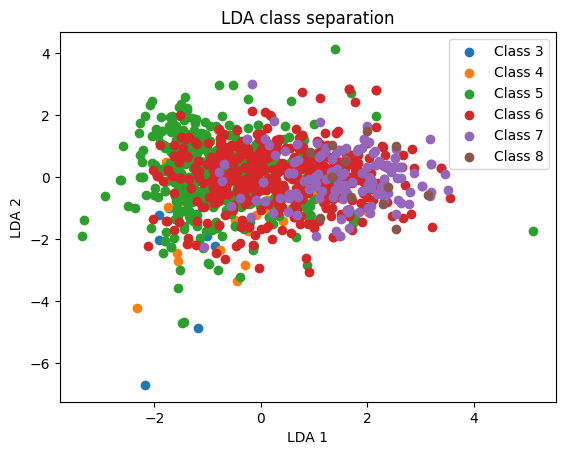

In [353]:
pairs = [(0,1), (0,2), (0,3), (0,4), (1,2)]

comp_x = 0
comp_y = 1

plt.figure()

for label in sorted(y_train.unique()):
    plt.scatter(X_train_lda[y_train==label, comp_x],
                X_train_lda[y_train==label, comp_y],
                label=f"Class {label}")

plt.xlabel("LDA 1")
plt.ylabel("LDA 2")
plt.legend()
plt.title("LDA class separation")
plt.show()


In [354]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train_lda,y_train)

LogisticRegression()

In [355]:
y_pred1=model.predict(X_test_lda)

In [356]:
print("Accuracy:", accuracy_score(y_test, y_pred1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("\nClassification Report:\n", classification_report(y_test, y_pred1))


Accuracy: 0.5625

Confusion Matrix:
 [[ 0  0  1  0  0  0]
 [ 0  1  7  2  0  0]
 [ 0  0 96 34  0  0]
 [ 0  0 46 76 10  0]
 [ 0  0  3 32  7  0]
 [ 0  0  0  1  4  0]]

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       1.00      0.10      0.18        10
           5       0.63      0.74      0.68       130
           6       0.52      0.58      0.55       132
           7       0.33      0.17      0.22        42
           8       0.00      0.00      0.00         5

    accuracy                           0.56       320
   macro avg       0.41      0.26      0.27       320
weighted avg       0.55      0.56      0.54       320



c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

In [357]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100, random_state=42)


In [358]:
rf.fit(X_train_lda,y_train)

RandomForestClassifier(random_state=42)

In [359]:
y_pred1=rf.predict(X_test_lda)

In [360]:
print("Accuracy:", accuracy_score(y_test, y_pred1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("\nClassification Report:\n", classification_report(y_test, y_pred1))


Accuracy: 0.64375

Confusion Matrix:
 [[  0   0   1   0   0   0]
 [  0   1   7   2   0   0]
 [  0   0 100  27   3   0]
 [  0   0  32  83  17   0]
 [  0   0   2  18  22   0]
 [  0   0   0   2   3   0]]

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       1.00      0.10      0.18        10
           5       0.70      0.77      0.74       130
           6       0.63      0.63      0.63       132
           7       0.49      0.52      0.51        42
           8       0.00      0.00      0.00         5

    accuracy                           0.64       320
   macro avg       0.47      0.34      0.34       320
weighted avg       0.64      0.64      0.63       320



c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

## Infrences based on LDA and without lda

The results show that using machine learning models with and without LDA makes a difference in how the classification works. When we use Logistic Regression and Decision Tree, without LDA we get results but when we add LDA with 5 components the results get better for most wine quality classes. LDA is helpful because it reduces the amount of information and makes it easier to tell the classes apart by putting the data into a space.. Even with LDA we can still see that some wine quality classes have similar features, which makes them hard to tell apart on the scatter plot. Overall, models combined with LDA performed better than those without LDA, and Decision Tree/Logistic with LDA provided more reliable classification compared to basic models.